# FX-Equity Performance

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Get Data

In [2]:
eq_path    = os.path.join("data", "ETFPX.parquet")
fut_path   = os.path.join("data", "FutPX.parquet")
guide_path = os.path.join("data", "ETFGuide.xlsx")

In [3]:
df_eq_spread = (pd.read_parquet(
    path = eq_path).
    pct_change().
    reset_index().
    melt(id_vars = ["SPY", "date"]).
    dropna().
    assign(spread = lambda x: x.value - x.SPY))

In [4]:
df_fut_rtn = (pd.read_parquet(
    path = fut_path).
    assign(security = lambda x: x.security.str.split("1").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna())

In [5]:
df_ticker_guide = (pd.read_excel(
    io = guide_path).
    query("group == 'liquid'").
    drop(columns = ["group"]).
    rename(columns = {
        "ticker"       : "fut_ticker",
        "etf_benchmark": "etf_ticker"}))

In [6]:
window    = 30
df_signal = (df_eq_spread.pivot(
    index = "date", columns = "ticker", values = "spread").
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
    shift().
    reset_index().
    melt(id_vars = "date", var_name = "etf_ticker", value_name = "signal").
    dropna())

In [7]:
df_combined = (df_fut_rtn.rename(
    columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_ticker_guide, how = "inner", on = ["fut_ticker"]).
    merge(right = df_signal, how = "inner", on = ["date", "etf_ticker"]))

# Trading Raw Z-Score

In [8]:
df_zscore_rtn = (df_combined.assign(
    signal_rtn = lambda x: -np.sign(x.signal) * x.fut_rtn).
    pivot(index = "date", columns = "fut_ticker", values = "signal_rtn"))

In [9]:
df_lagged = (df_zscore_rtn.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(group = "lagged"))

df_perf = (df_zscore_rtn.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(group = "perf"))

df_combined = pd.concat([df_lagged, df_perf])

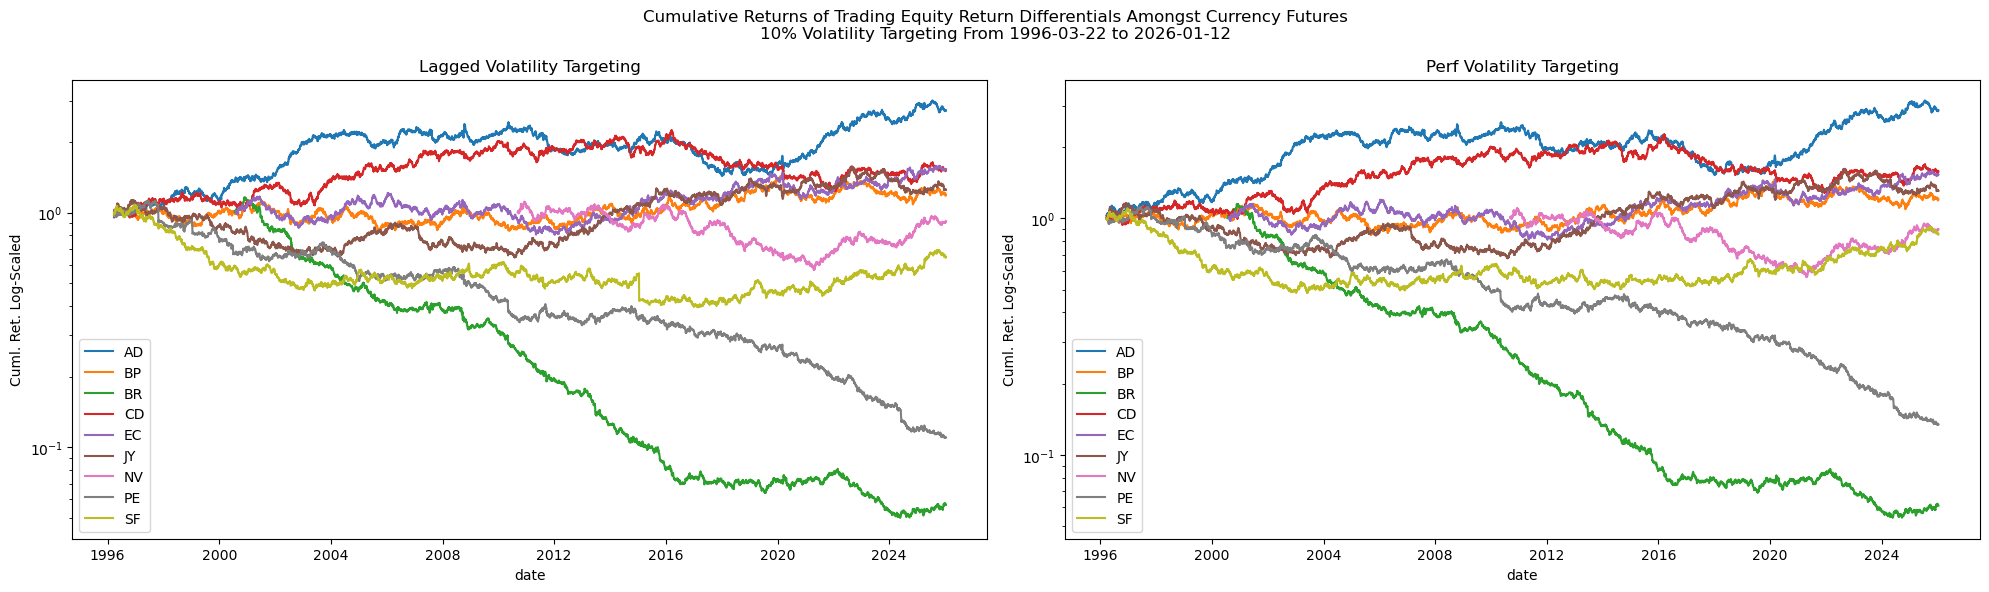

In [10]:
group_vars = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_combined.query(
        "group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var.capitalize() + " Volatility Targeting"))

fig.suptitle("Cumulative Returns of Trading Equity Return Differentials Amongst Currency Futures\n10% Volatility Targeting From {} to {}".format(
    df_combined.date.min(),
    df_combined.date.max()))
plt.tight_layout()

In [11]:
(df_combined.drop(
    columns = ["date"]).
    groupby(["fut_ticker", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"     : "",
        "fut_ticker": "Fut Ticker"}).
    replace({
        "lagged": "Lagged Vol",
        "perf"  : "Perfect Vol"}).
    pivot(index = "", columns = "Fut Ticker", values = "rtn").
    apply(lambda x: np.round(x,3)))

Fut Ticker,AD,BP,BR,CD,EC,JY,NV,PE,SF
,,,,,,,,,
Lagged Vol,0.384,0.110,-1.074,0.192,0.219,0.125,-0.006,-0.671,-0.080
Perfect Vol,0.413,0.114,-1.091,0.207,0.222,0.142,-0.021,-0.654,-0.005


# Trading Deciles

In [12]:
df_decile = (df_eq_spread.pivot(
    index = "date", columns = "ticker", values = "spread").
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
    apply(lambda x: pd.qcut(x = x, q = 10, labels = [i + 1 for i in range(10)])).
    shift().
    reset_index().
    melt(id_vars = "date", var_name = "etf_ticker", value_name = "decile").
    dropna())

In [13]:
df_combined = (df_fut_rtn.rename(
    columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_ticker_guide, how = "inner", on = ["fut_ticker"]).
    merge(right = df_decile, how = "inner", on = ["date", "etf_ticker"]))

In [14]:
df_decile_sharpe = (df_combined.drop(
    columns = ["date", "name", "etf_ticker"]).
    groupby(["fut_ticker", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

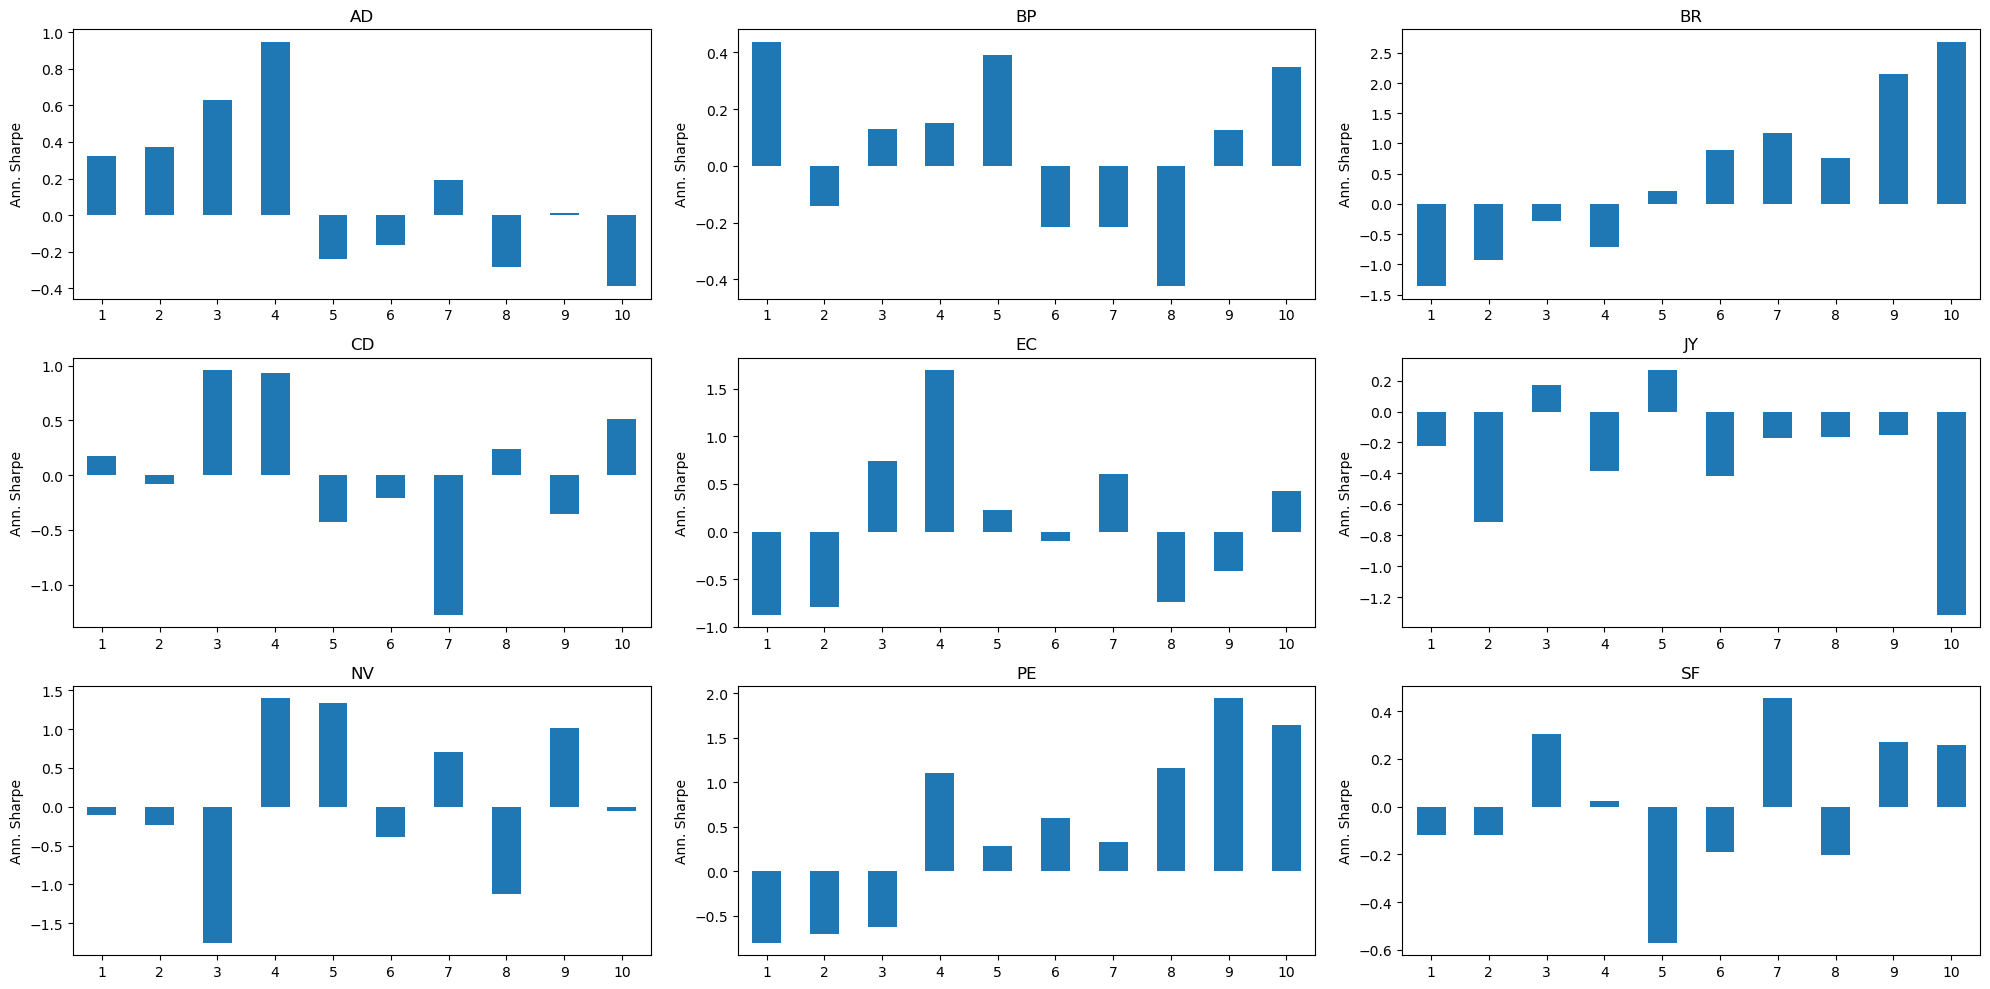

In [15]:
tickers = df_decile_sharpe.fut_ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 3, nrows = 3, figsize = (20,10))

for ticker, ax in zip(tickers, axes.flatten()):

    (df_decile_sharpe.query(
        "fut_ticker == @ticker").
        set_index("decile")
        [["sharpe"]].
        plot(
            kind   = "bar", 
            ax     = ax,
            legend = False,
            rot    = 0,
            xlabel = "",
            ylabel = "Ann. Sharpe",
            title  = ticker))

plt.tight_layout()

In [16]:
df_decile_tmp = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lower_group", "upper_group")))

In [17]:
df_sig_map = (df_decile_tmp.drop(
    columns = ["decile"]).
    groupby(["fut_ticker", "group"]).
    agg("prod").
    reset_index().
    rename(columns = {"sharpe": "raw_scaler"}).
    merge(right = df_decile_tmp, how = "inner", on = ["fut_ticker", "group"]).
    assign(signal = lambda x: np.where(x.raw_scaler > 0.1, x.sharpe, 0))
    [["fut_ticker", "decile", "signal"]])

In [18]:
df_sig_rtn_tmp = (df_combined.merge(
    right = df_sig_map, how = "left", on = ["fut_ticker", "decile"]).
    assign(signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn))

In [19]:
df_sig_wider = (df_sig_rtn_tmp.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn"))

In [20]:
df_lagged = (df_sig_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(vol_group = "lagged"))

df_perf = (df_sig_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(vol_group = "perfect"))

In [21]:
df_sig_rtn = (pd.concat([
    df_lagged, df_perf]))

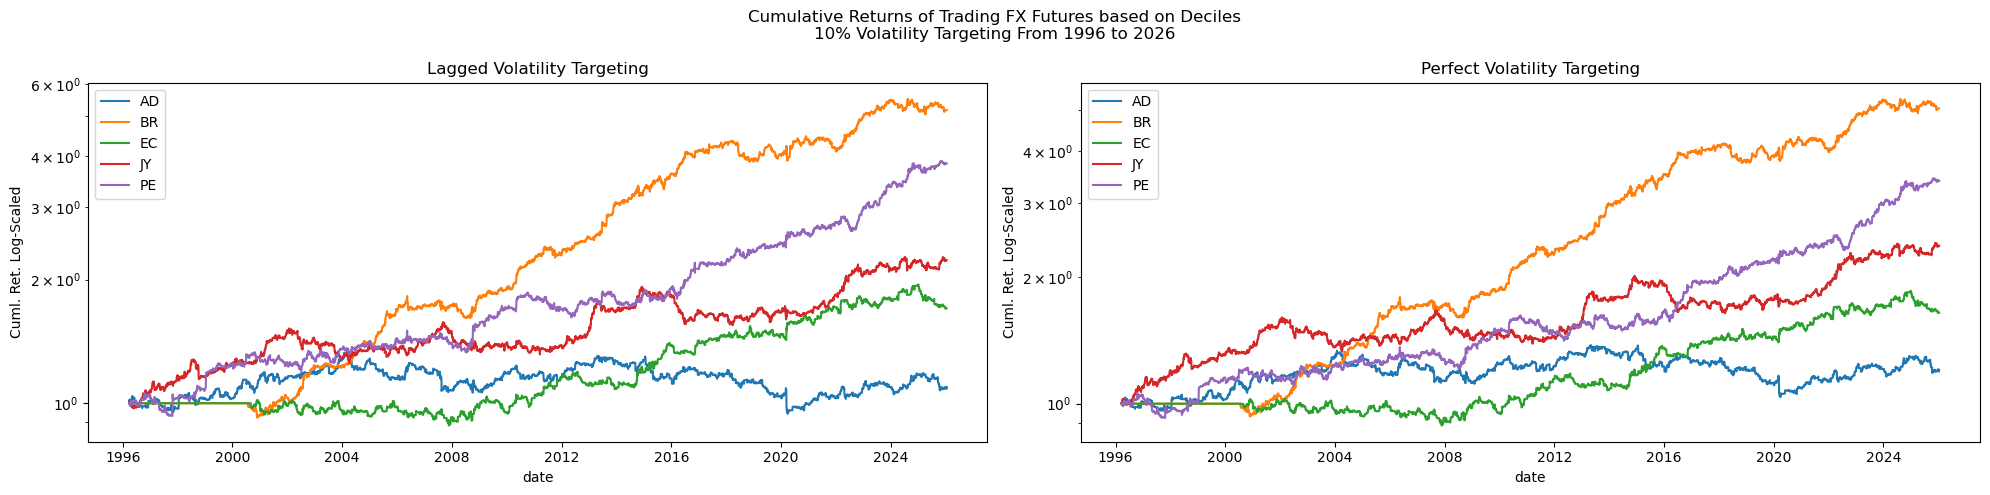

In [22]:
group_vars = df_sig_rtn.vol_group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,5))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_sig_rtn.query(
        "vol_group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            title  = group_var.capitalize() + " Volatility Targeting",
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Returns of Trading FX Futures based on Deciles\n10% Volatility Targeting From {} to {}".format(
    df_sig_rtn.date.min().year,
    df_sig_rtn.date.max().year))

plt.tight_layout()

In [23]:
(df_sig_rtn.drop(
    columns = ["date"]).
    groupby(["fut_ticker", "vol_group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(vol_group = lambda x: x.vol_group.str.capitalize()).
    rename(columns = {
        "vol_group" : "Vol Target",
        "fut_ticker": ""}).
    pivot(index = "", columns = "Vol Target", values = "rtn").
    apply(lambda x: np.round(x,3)))

Vol Target,Lagged,Perfect
,,
AD,0.125,0.212
BR,1.638,1.697
EC,0.572,0.569
JY,0.714,0.796
PE,1.116,1.118


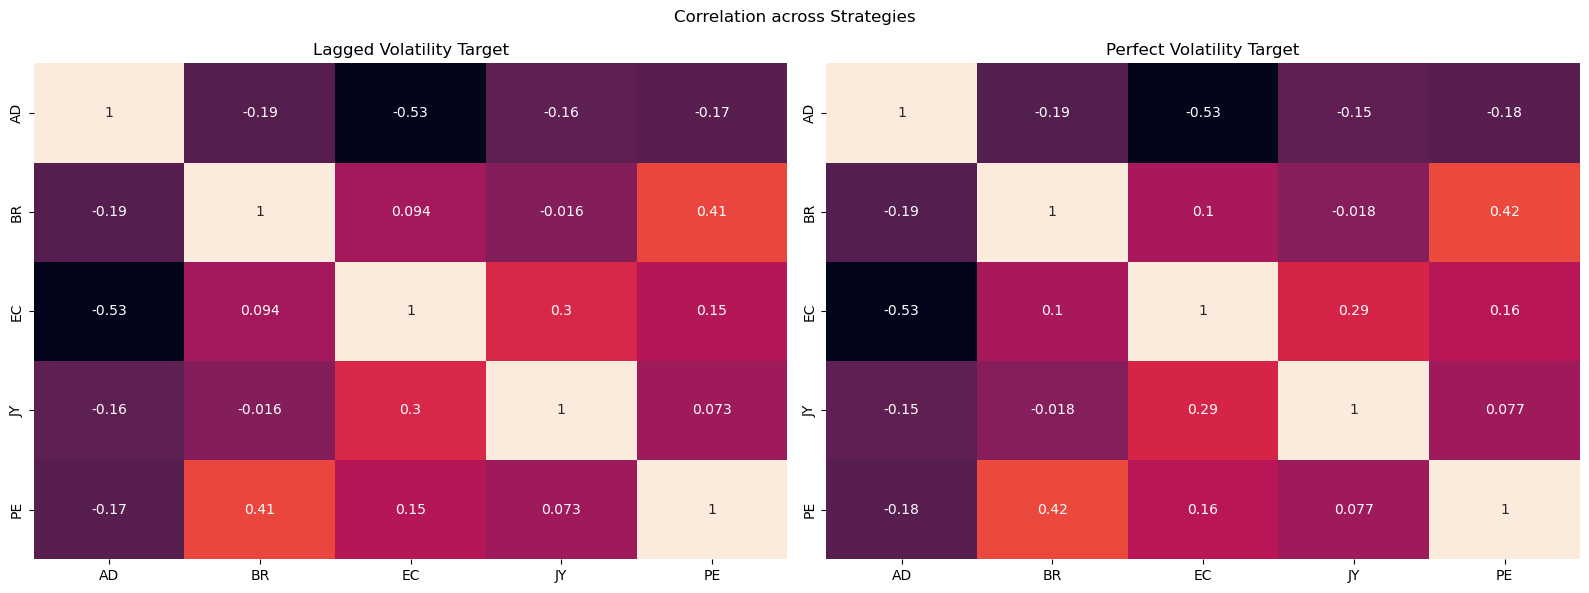

In [24]:
group_vars = df_sig_rtn.vol_group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (16,6))

for group_var, ax in zip(group_vars, axes.flatten()): 

    df_corr = (df_sig_rtn.query(
        "vol_group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        corr().
        apply(lambda x: np.round(x,3)))

    (sns.heatmap(
        data  = df_corr,
        ax    = ax,
        cbar  = False,
        annot = True))

    ax.set_title(group_var.capitalize() + " Volatility Target")

fig.suptitle("Correlation across Strategies")
plt.tight_layout()

In [25]:
(df_sig_rtn.rename(
    columns = {"rtn": "raw_rtn"}).
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "fut_ticker", "vol_group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["fut_ticker", "vol_group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "vol_group" : "Vol Target",
        "variable"  : "",
        "fut_ticker": "Fut"}).
    replace({
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Sharpe",
        "lagged" : "Lagged",
        "perfect": "Perfect"}).
    pivot(index = "Fut", columns = ["Vol Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol Target     Lagged               Perfect           
           Adj Sharpe Raw Sharpe Adj Sharpe Raw Sharpe
Fut                                                   
AD              0.177      0.125      0.300      0.212
BR              1.661      1.638      1.721      1.697
EC              0.813      0.572      0.809      0.569
JY              0.718      0.714      0.801      0.796
PE              1.133      1.116      1.134      1.118

In [26]:
df_port = (df_sig_rtn.drop(
    columns = ["fut_ticker"]).
    query("rtn != 0").
    groupby(["date", "vol_group"]).
    agg("mean").
    reset_index())

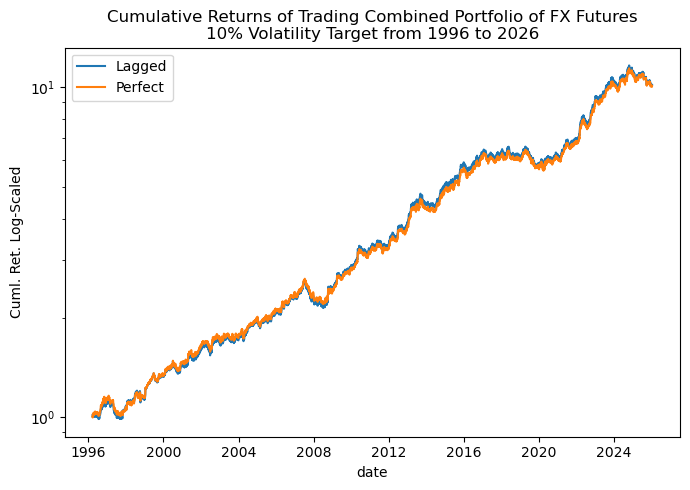

In [27]:
(df_port.assign(
    vol_group = lambda x: x.vol_group.str.capitalize()).
    rename(columns = {"vol_group": ""}).
    pivot(index = "date", columns = "", values = "rtn").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (7,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading Combined Portfolio of FX Futures\n10% Volatility Target from {} to {}".format(
            df_port.date.min().year,
            df_port.date.max().year)))

plt.tight_layout()

In [28]:
(df_port.rename(columns = {
    "rtn": "raw_rtn"}).
    assign(adj_rtn = lambda x: np.where(x.raw_rtn != 0, x.raw_rtn, np.nan)).
    melt(id_vars = ["date", "vol_group"]).
    drop(columns = ["date"]).
    groupby(["vol_group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(vol_group = lambda x: x.vol_group.str.capitalize()).
    rename(columns = {
        "vol_group": "Vol Target",
        "variable" : ""}).
    pivot(index = "Vol Target", columns = "", values = "value").
    rename(columns = {
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Adj Sharpe,Raw Sharpe
Vol Target,,
Lagged,1.119,1.119
Perfect,1.184,1.184


# Trading Residuals of Z-Score

In [31]:
df_combined = (df_fut_rtn.rename(
    columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_ticker_guide, how = "inner", on = ["fut_ticker"]).
    merge(right = df_signal, how = "inner", on = ["date", "etf_ticker"]))

In [46]:
def _get_resid(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.signal)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = 10, labels = [i + 1 for i in range(10)]).shift()).
        dropna().
        merge(right = df, how = "inner", on = ["date"]))

    return df_out

df_ols = (df_combined.assign(
    group_var = lambda x: x.fut_ticker + " " + x.etf_ticker).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index().
    assign(signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn))

In [52]:
df_lagged = (df_ols.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "lagged"))

In [53]:
df_perf = (df_ols.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "perfect"))

In [55]:
df_combined = (pd.concat([df_perf, df_lagged]))

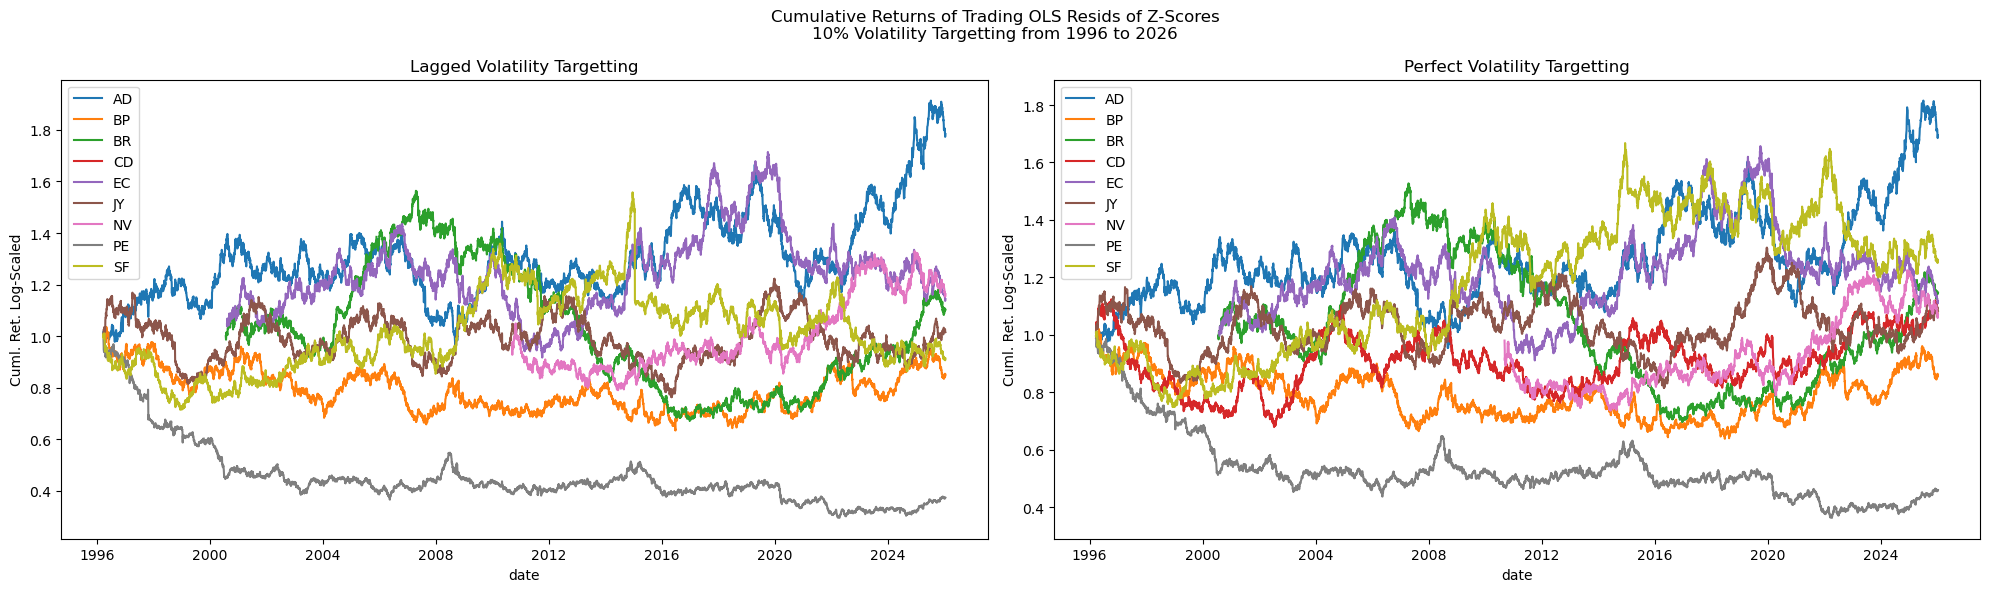

In [62]:
group_vars = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()):

    (df_combined.query(
        "group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Returns of Trading OLS Resids of Z-Scores\n10% Volatility Targetting from {} to {}".format(
    df_combined.date.min().year,
    df_combined.date.max().year))

plt.tight_layout()

# Trading Residuals Deciles

In [66]:
df_decile_sharpe = (df_ols[
    ["fut_ticker", "decile", "fut_rtn"]].
    groupby(["fut_ticker", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

In [67]:
df_decile_tmp = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lgroup", "ugroup")))

In [73]:
df_opt_rtn = (df_decile_tmp.drop(
    columns = ["decile"]).
    groupby(["fut_ticker", "group"]).
    agg("prod").
    reset_index().
    assign(signal_scaler = lambda x: np.where(x.sharpe > 0, 1, 0)).
    drop(columns = ["sharpe"]).
    merge(right = df_decile_tmp, how = "outer", on = ["fut_ticker", "group"]).
    merge(right = df_ols, how = "inner", on = ["fut_ticker", "decile"]).
    assign(signal_rtn = lambda x: np.sign(x.sharpe * x.signal_scaler) * x.fut_rtn))

In [87]:
df_lagged = (df_opt_rtn.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "lagged"))

df_perf = (df_opt_rtn.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "perfect"))

In [88]:
df_combined = pd.concat([df_lagged, df_perf])

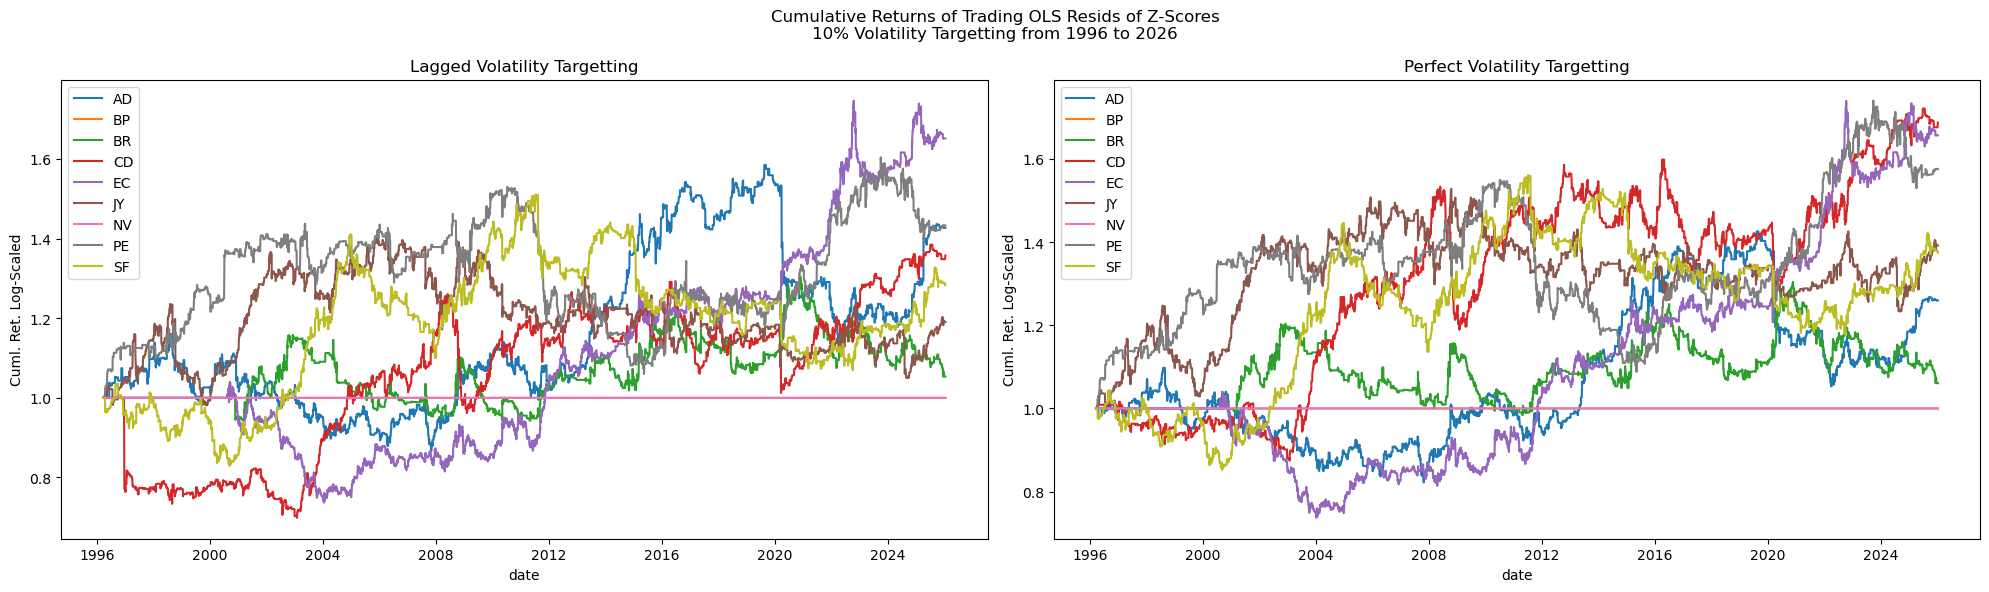

In [91]:
group_vars = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()):

    (df_combined.query(
        "group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Returns of Trading OLS Resids of Z-Scores\n10% Volatility Targetting from {} to {}".format(
    df_combined.date.min().year,
    df_combined.date.max().year))

plt.tight_layout()

In [106]:
(df_combined.rename(
    columns = {"rtn": "adj_rtn"}).
    assign(raw_rtn = lambda x: np.where(x.adj_rtn != x.adj_rtn, 0, x.adj_rtn)).
    melt(id_vars = ["date", "fut_ticker", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["fut_ticker", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(group = lambda x: x.group.str.capitalize()).
    rename(columns = {
        "group"     : "Vol. Target",
        "variable"  : "",
        "fut_ticker": "Future"}).
    replace({
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    pivot(index = "Future", columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

C:\Users\Diego\AppData\Local\Temp\ipykernel_25484\4077076541.py:8: RuntimeWarning: invalid value encountered in scalar divide
  agg(lambda x: x.mean() / x.std() * np.sqrt(252)).


Vol. Target     Lagged               Perfect           
            Adj Sharpe Raw Sharpe Adj Sharpe Raw Sharpe
Future                                                 
AD               0.335      0.220      0.251      0.165
BP                 NaN        NaN        NaN        NaN
BR               0.102      0.062      0.110      0.066
CD               0.274      0.180      0.503      0.331
EC               0.542      0.329      0.559      0.340
JY               0.192      0.126      0.342      0.225
NV                 NaN        NaN        NaN        NaN
PE               0.339      0.222      0.449      0.294
SF               0.254      0.167      0.329      0.216

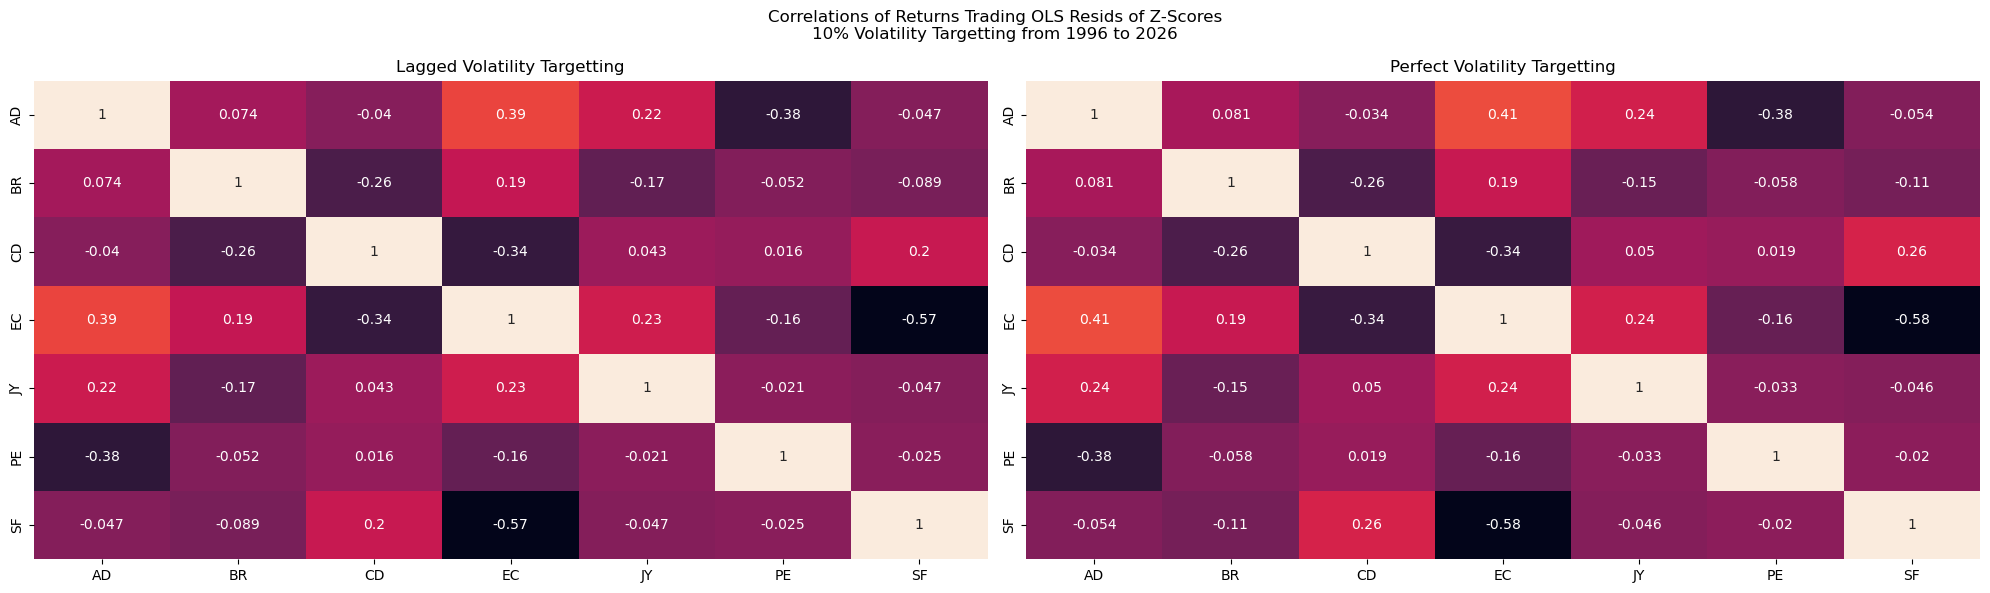

In [111]:
group_vars = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()):

    df_corr = (df_combined.query(
        "group == @group_var").
        dropna().
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        corr())

    sns.heatmap(
        data  = df_corr,
        ax    = ax,
        cbar  = False,
        annot = True)

    ax.set_title(group_var.capitalize() + " Volatility Targetting")

fig.suptitle("Correlations of Returns Trading OLS Resids of Z-Scores\n10% Volatility Targetting from {} to {}".format(
    df_combined.date.min().year,
    df_combined.date.max().year))

plt.tight_layout()

In [123]:
df_port = (df_combined.drop(
    columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "group"]).
    agg("mean").
    reset_index())

In [135]:
(df_port.pivot(
    index = "date", columns = "group", values = "rtn").
    fillna(0).
    reset_index().
    melt(id_vars = "date", value_name = "raw_rtn").
    assign(adj_rtn = lambda x: np.where(x.raw_rtn != 0, x.raw_rtn, np.nan)).
    melt(id_vars = ["date", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(group = lambda x: x.group.str.capitalize()).
    rename(columns = {"variable": ""}).
    pivot(index = "group", columns = "", values = "value").
    apply(lambda x: np.round(x,3)).
    rename(columns = {
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Rtn"}))

,Adj Sharpe,Raw Rtn
group,,
Lagged,0.548,0.502
Perfect,0.650,0.596


# Combining Portfolios